# LQR on a Double Integrator

System: $x_{t+1} = A x_t + B u_t$, cost $J=\sum (x_t^T Q x_t + u_t^T R u_t)$.

Optimal $u_t=-Kx_t$, with $K=(B^T P B + R)^{-1} B^T P A$ and $P$ solving the DARE.

We can change `Q` and `R` to see the trade-offs.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def double_integrator(dt: float):
    A = np.array([[1.0, dt],
                  [0.0, 1.0]])
    B = np.array([[0.5 * dt**2],
                  [dt]])
    return A, B

def dare_iterative(A, B, Q, R, max_iters=5000, tol=1e-10):
    P = Q.copy()
    for _ in range(max_iters):
        P_next = A.T @ P @ A - A.T @ P @ B @ np.linalg.inv(R + B.T @ P @ B) @ B.T @ P @ A + Q
        if np.linalg.norm(P_next - P, ord='fro') < tol:
            P = P_next
            break
        P = P_next
    K = np.linalg.inv(R + B.T @ P @ B) @ (B.T @ P @ A)
    return P, K

def simulate_closed_loop(A, B, K, x0, T, dt=0.05, u_sat=None):
    n = A.shape[0]
    x_hist = np.zeros((T, n))
    u_hist = np.zeros(T)
    x = x0.copy()
    for t in range(T):
        u = - (K @ x).item()
        if u_sat is not None:
            u = np.clip(u, -u_sat, u_sat)
        x_hist[t] = x
        u_hist[t] = u
        x = A @ x + B.flatten() * u
    return x_hist, u_hist


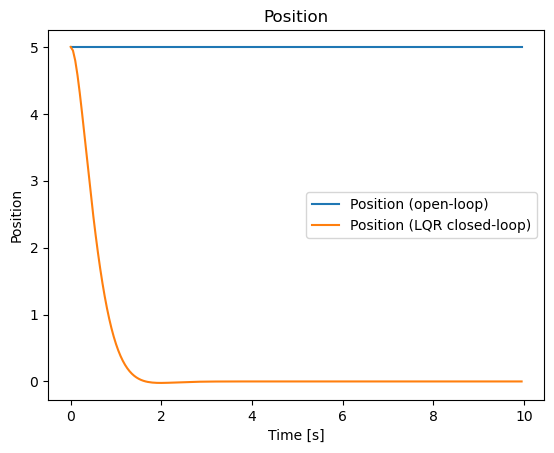

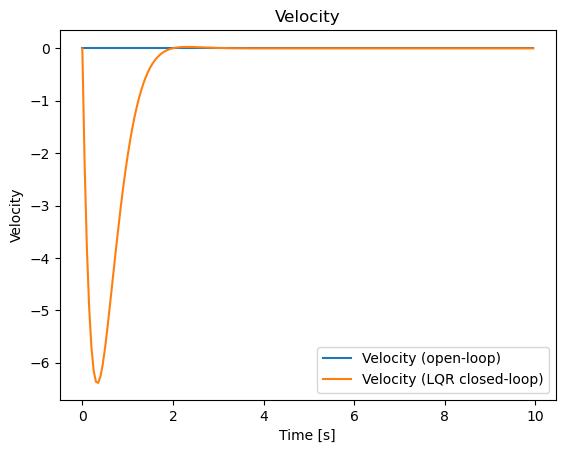

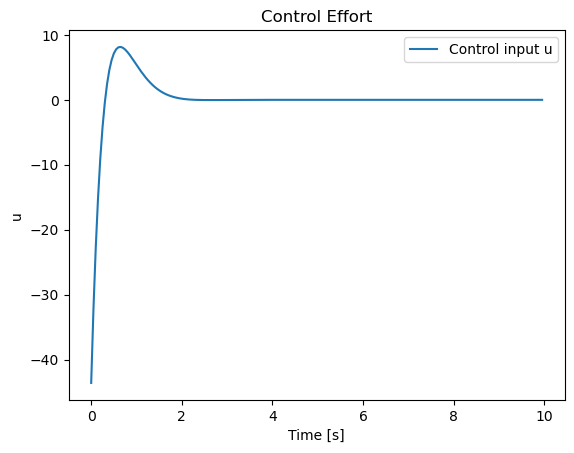

K =
 [[8.72154739 5.00496091]]
P =
 [[114.77231463  20.06240265]
 [ 20.06240265  11.51148188]]


In [ ]:
dt = 0.05
A, B = double_integrator(dt)

Q = np.diag([10.0, 1.0])  # tweak me
R = np.array([[0.1]])  # tweak me

P, K = dare_iterative(A, B, Q, R)

T = 200
x0 = np.array([5.0, 0.0])
x_hist, u_hist = simulate_closed_loop(A, B, K, x0, T, dt)
x_hist_open, _ = simulate_closed_loop(A, B, K=np.zeros((1,2)), x0=x0, T=T, dt=dt)

t = np.arange(T) * dt

plt.figure()
plt.plot(t, x_hist_open[:, 0], label='Position (open-loop)')
plt.plot(t, x_hist[:, 0], label='Position (LQR closed-loop)')
plt.xlabel('Time [s]'); plt.ylabel('Position'); plt.title('Position'); plt.legend(); plt.show()

plt.figure()
plt.plot(t, x_hist_open[:, 1], label='Velocity (open-loop)')
plt.plot(t, x_hist[:, 1], label='Velocity (LQR closed-loop)')
plt.xlabel('Time [s]'); plt.ylabel('Velocity'); plt.title('Velocity'); plt.legend(); plt.show()

plt.figure()
plt.plot(t, u_hist, label='Control input u')
plt.xlabel('Time [s]'); plt.ylabel('u'); plt.title('Control Effort'); plt.legend(); plt.show()

print('K =\n', K)
print('P =\n', P)
